         X1        X2  TrueCluster
0  0.548383 -0.225879            1
1  0.145251  0.253145            1
2  0.161707 -0.042450            1
3  0.604609 -0.037864            1
4  0.807369 -0.025086            1


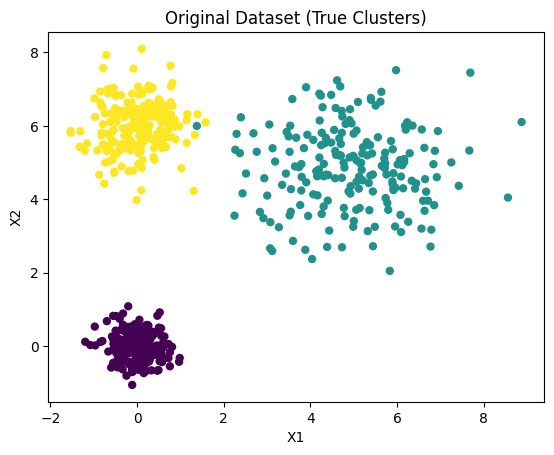

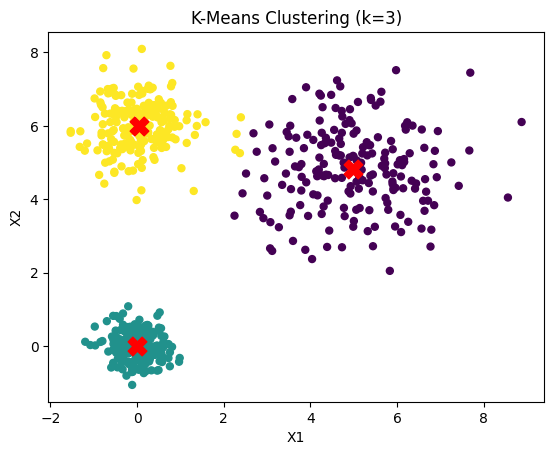

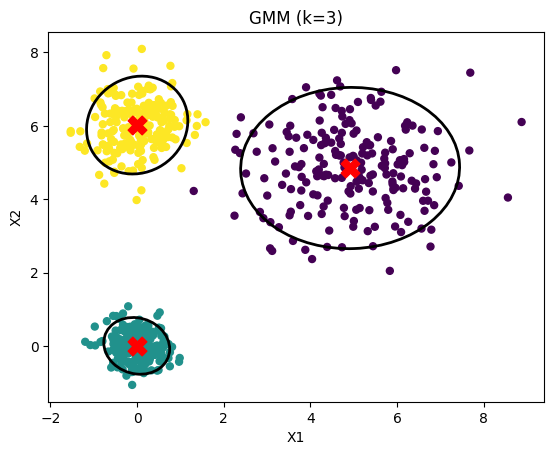

ARI Kmeans : 0.9752324006948598
ARI GMM    : 0.9900166666666667

Observation: GMM handles overlaps better.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score
from matplotlib.patches import Ellipse

# ====== LOAD CSV ======
df = pd.read_csv("/content/syndata.csv")

# rename to uniform naming (only naming change required)
df = df.rename(columns={
    df.columns[0]:"X1",
    df.columns[1]:"X2",
    df.columns[-1]:"TrueCluster"
})

X = df[["X1","X2"]].values
y_true = df["TrueCluster"].values

print(df.head())

# ==== ground truth plot ====
plt.scatter(df.X1, df.X2, c=y_true, cmap="viridis", s=25)
plt.title("Original Dataset (True Clusters)")
plt.xlabel("X1"); plt.ylabel("X2")
plt.show()

# ==== KMeans ====
kmeans = KMeans(n_clusters=3, n_init="auto", random_state=42)
labels_km = kmeans.fit_predict(X)

plt.scatter(df.X1, df.X2, c=labels_km, cmap="viridis", s=25)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            c="red", marker="X", s=180)
plt.title("K-Means Clustering (k=3)")
plt.xlabel("X1"); plt.ylabel("X2")
plt.show()

# ==== GMM ====
gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=42)
labels_gmm = gmm.fit_predict(X)

fig, ax = plt.subplots()
ax.scatter(df.X1, df.X2, c=labels_gmm, cmap="viridis", s=25)
ax.scatter(gmm.means_[:,0], gmm.means_[:,1], c="red", marker="X", s=180)

def draw_ellipse(mean, cov, ax, nsig=2):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:,order]
    width, height = 2*nsig*np.sqrt(vals)
    angle = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                  fill=False, lw=2)
    ax.add_patch(ell)

for m, c in zip(gmm.means_, gmm.covariances_):
    draw_ellipse(m, c, ax)

ax.set_title("GMM (k=3)")
ax.set_xlabel("X1"); ax.set_ylabel("X2")
plt.show()

# ===== comparison =====
ari_km  = adjusted_rand_score(y_true, labels_km)
ari_gmm = adjusted_rand_score(y_true, labels_gmm)

print("ARI Kmeans :", ari_km)
print("ARI GMM    :", ari_gmm)

print("\nObservation:", "GMM handles overlaps better."
      if ari_gmm > ari_km else "K-Means performed similarly or better here.")